# Chapter 13: Evaluating Biomedical AI Systems

## Hands-On Jupyter Notebook

This notebook evaluates biomedical AI outputs using synthetic predictions, subgroup checks, and calibration-style summaries.

**Time to Complete**: 1-2 hours

---

## Section 1: Setup and Imports

We prepare deterministic evaluation utilities for biomedical AI model assessment.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Configuration
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 13 evaluation notebook.')

Environment configured for Chapter 13 evaluation notebook.


## Section 2: Load Data and Explore

We create a compact synthetic benchmark with labels, predictions, confidence, and subgroup tags.

In [2]:
evaluation_df = pd.DataFrame([
    {'case_id': 'eval_01', 'subgroup': 'lung', 'label': 1, 'prediction': 1, 'confidence': 0.91},
    {'case_id': 'eval_02', 'subgroup': 'lung', 'label': 0, 'prediction': 0, 'confidence': 0.78},
    {'case_id': 'eval_03', 'subgroup': 'colorectal', 'label': 1, 'prediction': 1, 'confidence': 0.83},
    {'case_id': 'eval_04', 'subgroup': 'colorectal', 'label': 0, 'prediction': 1, 'confidence': 0.69},
    {'case_id': 'eval_05', 'subgroup': 'breast', 'label': 1, 'prediction': 1, 'confidence': 0.88},
    {'case_id': 'eval_06', 'subgroup': 'breast', 'label': 0, 'prediction': 0, 'confidence': 0.74},
])
evaluation_df['correct'] = evaluation_df['label'] == evaluation_df['prediction']
display(evaluation_df)

,case_id,subgroup,label,prediction,confidence,correct
0,eval_01,lung,1,1,0.91,True
1,eval_02,lung,0,0,0.78,True
2,eval_03,colorectal,1,1,0.83,True
3,eval_04,colorectal,0,1,0.69,False
4,eval_05,breast,1,1,0.88,True
5,eval_06,breast,0,0,0.74,True


## Section 3: Main Analysis

We compute pooled and subgroup metrics to inspect overall and stratified performance.

In [3]:
def safe_rate(numerator: int, denominator: int) -> float:
    return round(numerator / denominator, 3) if denominator else 0.0

tp = int(((evaluation_df['prediction'] == 1) & (evaluation_df['label'] == 1)).sum())
pred_pos = int((evaluation_df['prediction'] == 1).sum())
actual_pos = int((evaluation_df['label'] == 1).sum())

overall_accuracy = safe_rate(int(evaluation_df['correct'].sum()), len(evaluation_df))
overall_precision = safe_rate(tp, pred_pos)
overall_recall = safe_rate(tp, actual_pos)
overall_f1 = round((2 * overall_precision * overall_recall / (overall_precision + overall_recall)) if (overall_precision + overall_recall) else 0.0, 3)

metrics_df = evaluation_df.groupby('subgroup', as_index=False).agg(cases=('case_id', 'count'), accuracy=('correct', 'mean'), avg_confidence=('confidence', 'mean'))
metrics_df['accuracy'] = metrics_df['accuracy'].round(3)
metrics_df['avg_confidence'] = metrics_df['avg_confidence'].round(3)
display(metrics_df)
print(f'Overall accuracy: {overall_accuracy}')
print(f'Overall precision: {overall_precision}')
print(f'Overall recall: {overall_recall}')
print(f'Overall F1: {overall_f1}')

,subgroup,cases,accuracy,avg_confidence
0,breast,2,1.0,0.810
1,colorectal,2,0.5,0.760
2,lung,2,1.0,0.845


Overall accuracy: 0.833
Overall precision: 0.75
Overall recall: 1.0
Overall F1: 0.857


## Section 4: Visualization

We visualize subgroup accuracy and the relationship between confidence and correctness.

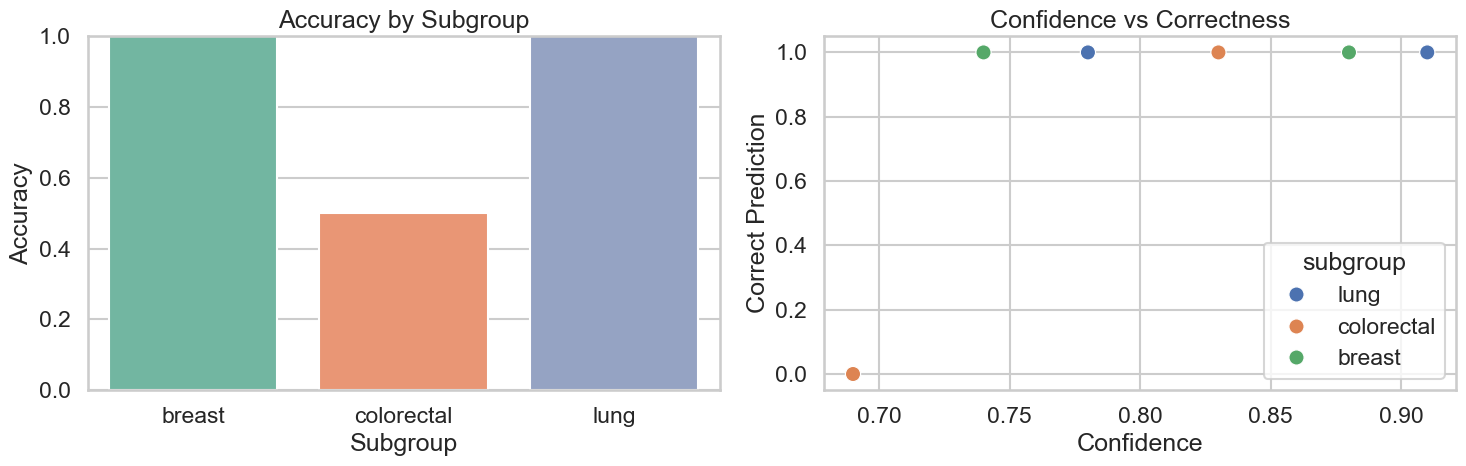

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=metrics_df, x='subgroup', y='accuracy', ax=axes[0], palette='Set2')
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy by Subgroup')
axes[0].set_xlabel('Subgroup')
axes[0].set_ylabel('Accuracy')

sns.scatterplot(data=evaluation_df, x='confidence', y='correct', hue='subgroup', s=120, ax=axes[1])
axes[1].set_title('Confidence vs Correctness')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Correct Prediction')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Error Audit

*Description: Identify false-positive and false-negative cases from the benchmark.*

In [5]:
errors_df = evaluation_df[evaluation_df['correct'] == False].copy()
errors_df['error_type'] = np.where(errors_df['prediction'] == 1, 'false_positive', 'false_negative')
display(errors_df[['case_id', 'subgroup', 'label', 'prediction', 'error_type']])

,case_id,subgroup,label,prediction,error_type
3,eval_04,colorectal,0,1,false_positive


### Exercise 2: Threshold Review

*Description: Simulate a stricter confidence threshold and count deferred cases.*

In [6]:
threshold_df = evaluation_df[['case_id', 'subgroup', 'confidence']].copy()
threshold_df['defer_review'] = threshold_df['confidence'] < 0.8
display(threshold_df)
print('Cases deferred under threshold:', int(threshold_df['defer_review'].sum()))

,case_id,subgroup,confidence,defer_review
0,eval_01,lung,0.91,False
1,eval_02,lung,0.78,True
2,eval_03,colorectal,0.83,False
3,eval_04,colorectal,0.69,True
4,eval_05,breast,0.88,False
5,eval_06,breast,0.74,True


Cases deferred under threshold: 3


## Section 6: Key Takeaways

- Evaluation should include subgroup checks, not only pooled metrics.
- Confidence scores help identify uncertain predictions for human review.
- Error audits expose false positives and false negatives relevant to care.

---

## Next Steps

1. ✅ Complete all exercises
2. 📖 Read Chapter 14 (next chapter)
3. 🔗 Review governance and calibration chapters as needed
4. 🧪 Extend this benchmark structure to your own model outputs

---

**Last Updated**: May 2026